# Session 6 Step 4: Factorial analysis and decision string

Reads the five Session 6 factorial runs (F-L, F-CD, F-NC, F-S, F-OBS)
together with the Session 5 Run A (SIGReg + BN baseline). For each run
it loads the iter=5000 checkpoint, encodes the 5-case Test A subset, and
computes the diagnostic axes from notebook 02.

Section 4 (the lift-prediction baseline) trains two tiny MLPs from
scratch in-notebook:

- `baseline_ct`  : maps `(c, t)` to `CL(t + delta)`
- `baseline_jepa`: maps `z_t`     to `CL(t + delta)`

If the JEPA baseline outperforms the c/t baseline on r2(CL_future) the
latent has learned dynamics; otherwise the latent is a glorified case
lookup. This is the central skill metric per the collaborator report.

Section 5 prints the Session 6 decision string from the
{CLEAN_ROOT_CAUSE, COMBINED_REMEDIATION, OBSERVABLE_REQUIRED, SCALE_BOUND,
ALL_AXES_FAIL, AMBIGUOUS} menu in SESSION6_FACTORIAL_DIAGNOSTIC.md.


In [1]:
from __future__ import annotations

import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
print('repo root:', REPO)

from src.data.episode_dataset import EpisodeDataset
from src.models.encoder import HybridCNNViTEncoder
from src.training.diagnostics import linear_probe_r2, participation_ratio

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
D = 32

PREVENT = Path(os.environ.get('PREVENT_ROOT', '/home/carlos/PREVENT'))
CACHE = Path(os.environ.get('VORTEX_JEPA_CACHE', PREVENT / 'data' / 'processed' / 'vortex-jepa'))


repo root: /home/carlos/GUST-JEPA
device: cuda


## Section 1: Load the six runs

Reads `metrics.jsonl` for loss curves and the iter=5000 checkpoint for
each run. The Session 5 Run A is at `outputs/runs/smoke5k/run_a_sigreg_bn/`
and the Session 6 variants are at `outputs/runs/session6/run_f_*/`.

In [2]:
RUN_SPECS = {
    'A (Session 5 baseline)':       (REPO / 'outputs' / 'runs' / 'smoke5k'  / 'run_a_sigreg_bn',      5000, None, 'jepa'),
    'PLDM-A (Session 5.PLDM)':      (REPO / 'outputs' / 'runs' / 'smoke5k'  / 'run_pldm_a',            5000, None, 'pldm'),
    'F-L (L=64)':                   (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_l',              5000, None, 'jepa'),
    'F-CD (c-dropout=0.5)':         (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_cd',             5000, None, 'jepa'),
    'F-NC (no c at predictor)':     (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_nc',             5000, None, 'jepa'),
    'F-S (24 cases)':               (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_s',              5000, None, 'jepa'),
    'F-OBS @ 5k':                   (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_obs',            5000, None, 'jepa'),
    'F-OBS @ 10k':                  (REPO / 'outputs' / 'runs' / 'session6' / 'run_f_obs_10k',       10000,
                                     REPO / 'outputs' / 'runs' / 'session6' / 'run_f_obs',  'jepa'),
    'PLDM+OBS':                     (REPO / 'outputs' / 'runs' / 'session6' / 'run_pldm_obs',         5000, None, 'pldm'),
}


def load_run(run_dir: Path, iters: int, prior_dir: Path | None = None, kind: str = 'jepa'):
    """Load encoder from <run_dir>/checkpoint_iter<iters:06d>.pt and concatenate
    metrics.jsonl with prior_dir's metrics.jsonl if a resume was used.

    kind='jepa' reads 'jepa_state_dict'; kind='pldm' reads 'wrapper_state_dict'.
    """
    ckpt = run_dir / f'checkpoint_iter{iters:06d}.pt'
    blob = torch.load(ckpt, map_location='cpu', weights_only=False)
    args = blob['args']
    enc = HybridCNNViTEncoder(
        latent_dim=int(args['d']),
        projection_norm=args.get('projection_norm', 'batchnorm'),
    )
    state_key = 'wrapper_state_dict' if kind == 'pldm' else 'jepa_state_dict'
    state = {k.removeprefix('encoder.'): v for k, v in blob[state_key].items()
             if k.startswith('encoder.')}
    enc.load_state_dict(state, strict=False)
    enc.eval().to(device)

    rows = []
    if prior_dir is not None:
        prior_metrics = prior_dir / 'metrics.jsonl'
        if prior_metrics.exists():
            with open(prior_metrics) as f:
                for line in f:
                    evt = json.loads(line)
                    if evt.get('event') == 'log':
                        rows.append(evt)
    metrics_path = run_dir / 'metrics.jsonl'
    with open(metrics_path) as f:
        for line in f:
            evt = json.loads(line)
            if evt.get('event') == 'log':
                rows.append(evt)
    # drop duplicates on (step) -- the resume re-logs the resumed iter
    df = pd.DataFrame(rows).drop_duplicates('step', keep='last').set_index('step') if rows else pd.DataFrame()
    return enc, args, df


loaded = {}
for label, (run_dir, iters, prior_dir, kind) in RUN_SPECS.items():
    ckpt = run_dir / f'checkpoint_iter{iters:06d}.pt'
    if not ckpt.exists():
        print(f'  MISSING: {label} ({ckpt})')
        continue
    enc, args, df = load_run(run_dir, iters, prior_dir, kind)
    loaded[label] = (enc, args, df, kind)
    print(f'  {label:35s} kind={kind} L={args["T"]} cond_dim={args.get("predictor_cond_dim", 3)} '
          f'c_dropout={args.get("c_dropout_prob", 0.0)} obs={args.get("observable_head", "none")} '
          f'iters={iters}')
print(f'loaded {len(loaded)} runs')


  A (Session 5 baseline)              kind=jepa L=32 cond_dim=3 c_dropout=0.0 obs=none iters=5000


  PLDM-A (Session 5.PLDM)             kind=pldm L=32 cond_dim=3 c_dropout=0.0 obs=none iters=5000


  F-L (L=64)                          kind=jepa L=64 cond_dim=3 c_dropout=0.0 obs=none iters=5000


  F-CD (c-dropout=0.5)                kind=jepa L=32 cond_dim=3 c_dropout=0.5 obs=none iters=5000


  F-NC (no c at predictor)            kind=jepa L=32 cond_dim=0 c_dropout=0.0 obs=none iters=5000


  F-S (24 cases)                      kind=jepa L=32 cond_dim=3 c_dropout=0.0 obs=none iters=5000


  F-OBS @ 5k                          kind=jepa L=32 cond_dim=3 c_dropout=0.0 obs=cl_future iters=5000


  F-OBS @ 10k                         kind=jepa L=32 cond_dim=3 c_dropout=0.0 obs=cl_future iters=10000


  PLDM+OBS                            kind=pldm L=32 cond_dim=3 c_dropout=0.0 obs=cl_future iters=5000
loaded 9 runs


## Section 2: Loss-curve panel

Three sub-panels: loss_pred, loss_roll, loss_anticollapse. Add a loss_obs
panel only if any run carries it (F-OBS).

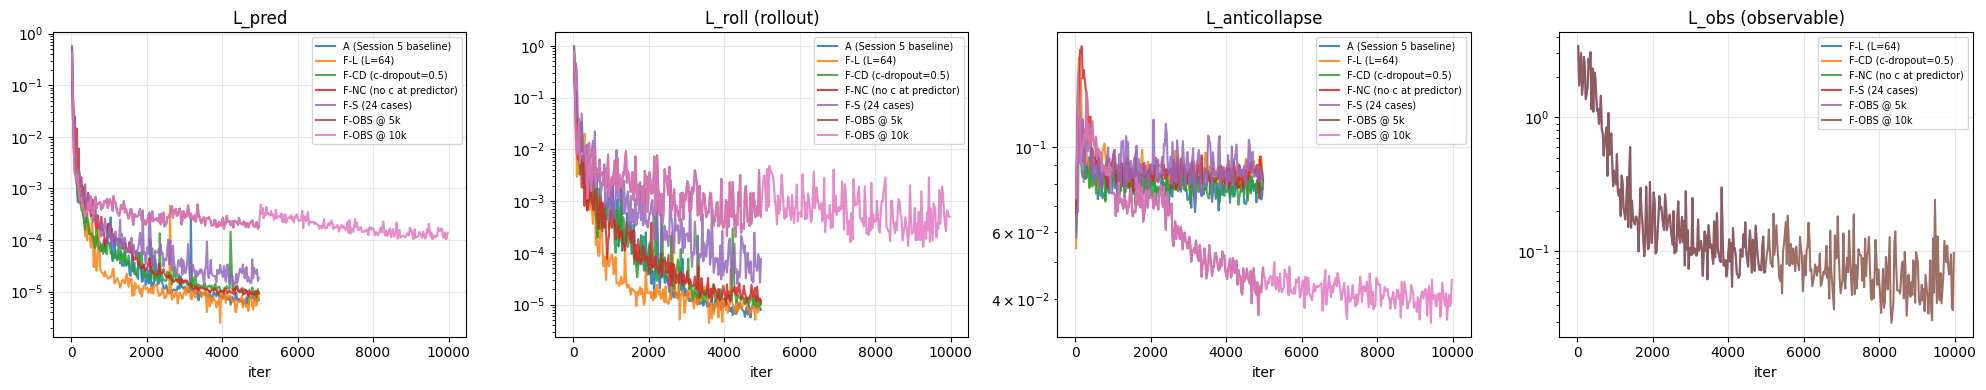

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
keys = ['loss_pred', 'loss_roll', 'loss_anticollapse', 'loss_obs']
titles = ['L_pred', 'L_roll (rollout)', 'L_anticollapse', 'L_obs (observable)']
for ax, key, title in zip(axes, keys, titles):
    for label, (_, _, df, _) in loaded.items():
        if key not in df.columns:
            continue
        sub = df[key].dropna()
        if sub.empty:
            continue
        ax.plot(sub.index, sub.values, label=label, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('iter')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


## Section 3: Re-encode 5-case Test A and compute the per-axis table

Uses notebook 02's static/dynamic decomposition. For F-S (which trained
on 24 cases) we still evaluate on the same Session 5 5-case Test A
subset so the metrics are comparable across all six runs.

In [4]:
SMOKE_CASES = yaml.safe_load(open(REPO / 'configs' / 'cases' / 'smoke_5cases.yaml'))['cases']


def gather_test_a():
    with open(REPO / 'configs' / 'splits' / 'split_v1.json') as f:
        split = json.load(f)
    encs = []
    for cid in SMOKE_CASES:
        case = split['cases'][cid]
        for k in case['test_a_encounter_indices']:
            path = CACHE / 'v1' / cid / f'encounter_{k:02d}.h5'
            with h5py.File(path, 'r') as g:
                encs.append({
                    'case_id': cid,
                    'encounter_index': int(k),
                    'omega_z': np.asarray(g['omega_z'], dtype=np.float32),
                    'C_L': np.asarray(g['C_L'], dtype=np.float32),
                    'G': float(g.attrs['G']),
                    'D': float(g.attrs['D']),
                    'Y': float(g.attrs['Y']),
                })
    return encs


ENCS = gather_test_a()
T_full = ENCS[0]['omega_z'].shape[0]
N_enc = len(ENCS)
print(f'{N_enc} Test A encounters from {len(set(e["case_id"] for e in ENCS))} cases; T={T_full}')

case_of_enc = np.array([e['case_id'] for e in ENCS])
G_of_enc = np.array([e['G'] for e in ENCS], dtype=np.float32)
D_of_enc = np.array([e['D'] for e in ENCS], dtype=np.float32)
Y_of_enc = np.array([e['Y'] for e in ENCS], dtype=np.float32)
c_of_enc = np.stack([G_of_enc, D_of_enc, Y_of_enc], axis=1)


def encode_all(enc):
    out = np.empty((N_enc, T_full, D), dtype=np.float32)
    with torch.no_grad():
        for i, ent in enumerate(ENCS):
            x = torch.from_numpy(ent['omega_z']).unsqueeze(1).to(device)
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == 'cuda'):
                z = enc(x.unsqueeze(0))
            out[i] = z.squeeze(0).float().cpu().numpy()
    return out


def split_static_dynamic(z_all):
    cases = sorted(set(case_of_enc))
    means = []
    for cid in cases:
        mask = case_of_enc == cid
        means.append(z_all[mask].reshape(-1, D).mean(axis=0))
    z_case_mean = np.stack(means, axis=0)
    cid_to_idx = {cid: i for i, cid in enumerate(cases)}
    z_dyn = z_all.copy()
    for i in range(z_all.shape[0]):
        z_dyn[i] -= z_case_mean[cid_to_idx[case_of_enc[i]]]
    return z_case_mean, z_dyn


def pr_of(arr_2d):
    return float(participation_ratio(torch.from_numpy(arr_2d.astype(np.float32))))


def probe_r2(z_2d, y_2d, seed=0):
    n = z_2d.shape[0]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    nfit = max(2, int(0.75 * n))
    fit, ev = perm[:nfit], perm[nfit:]
    if ev.size < 2:
        fit, ev = perm[:n // 2], perm[n // 2:]
    r2 = linear_probe_r2(
        torch.from_numpy(z_2d.astype(np.float32)),
        torch.from_numpy(y_2d.astype(np.float32)),
        torch.from_numpy(fit), torch.from_numpy(ev),
    )
    return float(r2['r2_overall']) if isinstance(r2, dict) else float(r2)


def metrics_for(z_all):
    z_cm, z_dyn = split_static_dynamic(z_all)
    z_flat = z_all.reshape(-1, D)
    z_dyn_flat = z_dyn.reshape(-1, D)
    c_rep = np.repeat(c_of_enc, T_full, axis=0)
    phase = np.tile(np.arange(T_full, dtype=np.float32), N_enc)[:, None]
    return {
        'PR_all': pr_of(z_flat),
        'PR_case_mean': pr_of(z_cm),
        'PR_within_case': float(np.mean([
            pr_of(z_dyn[case_of_enc == cid].reshape(-1, D)) for cid in sorted(set(case_of_enc))
        ])),
        'r2_z_to_c': probe_r2(z_flat, c_rep),
        'r2_z_dyn_to_c': probe_r2(z_dyn_flat, c_rep),
        'r2_z_to_phase': probe_r2(z_flat, phase),
        'r2_z_dyn_to_phase': probe_r2(z_dyn_flat, phase),
        'frac_dyn_norm': float(np.linalg.norm(z_dyn) / np.linalg.norm(z_all)),
    }


encoded = {label: encode_all(enc) for label, (enc, _, _, _) in loaded.items()}
rows = [{'run': label, **metrics_for(z)} for label, z in encoded.items()]
df_metrics = pd.DataFrame(rows).set_index('run')
df_metrics.round(3)


6 Test A encounters from 5 cases; T=120


,PR_all,PR_case_mean,PR_within_case,r2_z_to_c,r2_z_dyn_to_c,r2_z_to_phase,r2_z_dyn_to_phase,frac_dyn_norm
run,,,,,,,,
A (Session 5 baseline),1.022,1.005,2.247,0.732,-0.166,0.129,0.131,0.102
PLDM-A (Session 5.PLDM),6.717,3.341,4.014,0.974,-0.088,0.581,0.583,0.840
F-L (L=64),1.012,1.006,3.247,0.834,-0.135,0.092,0.106,0.092
F-CD (c-dropout=0.5),1.027,1.006,2.720,0.549,-0.151,0.157,0.154,0.234
F-NC (no c at predictor),1.019,1.006,5.857,0.382,-0.129,0.139,0.164,0.056
F-S (24 cases),1.030,1.004,1.478,0.460,-0.084,0.077,0.095,0.064
F-OBS @ 5k,3.207,2.495,3.526,0.992,-0.099,0.432,0.472,0.224
F-OBS @ 10k,3.407,2.626,3.586,0.989,-0.119,0.306,0.447,0.212
PLDM+OBS,6.089,3.233,4.769,0.973,-0.126,0.557,0.538,0.822


## Section 4: Lift-prediction baseline comparison

Trains two tiny MLPs in-notebook on Test A frames (omitted only because
re-encoding is more expensive than a 5-min MLP fit).

- `baseline_ct(c, t) -> CL(t + delta)`     : if the latent isn't doing
  anything beyond a fancy lookup of (case_id, frame_index), the JEPA
  side cannot beat this baseline.
- `baseline_jepa(z_t) -> CL(t + delta)`    : if z_t encodes the
  aerodynamic state, the JEPA baseline is materially better.

Reports r2 averaged over the three deltas (8, 16, 24).

In [5]:
import torch.nn as nn
import torch.nn.functional as F

DELTAS = (8, 16, 24)


def build_cl_future(encs):
    cl_future = np.empty((len(encs), T_full, len(DELTAS)), dtype=np.float32)
    for i, ent in enumerate(encs):
        cl_full = ent['C_L']
        for j, d in enumerate(DELTAS):
            for t in range(T_full):
                src = t + d
                cl_future[i, t, j] = cl_full[src] if src < cl_full.shape[0] else cl_full[-1]
    return cl_future


CL_FUTURE = build_cl_future(ENCS)
print(f'CL_future shape={CL_FUTURE.shape}  finite={np.isfinite(CL_FUTURE).all()}')


def fit_mlp(X, y, seed=0, hidden=64, epochs=400, lr=1e-2):
    torch.manual_seed(seed)
    n, in_dim = X.shape
    out_dim = y.shape[1]
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    fit, ev = perm[: int(0.75 * n)], perm[int(0.75 * n):]
    X_t = torch.from_numpy(X.astype(np.float32))
    y_t = torch.from_numpy(y.astype(np.float32))
    model = nn.Sequential(
        nn.Linear(in_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim),
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        p = model(X_t[fit])
        loss = F.mse_loss(p, y_t[fit])
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        p_ev = model(X_t[ev])
    ss_res = ((y_t[ev] - p_ev) ** 2).sum(dim=0)
    ss_tot = ((y_t[ev] - y_t[ev].mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)
    r2 = (1.0 - ss_res / ss_tot).mean().item()
    return float(r2)


# Build inputs for the c/t baseline: (G, D, Y, t) per frame
c_t_X = np.empty((N_enc * T_full, 4), dtype=np.float32)
for i in range(N_enc):
    c_t_X[i*T_full:(i+1)*T_full, 0] = c_of_enc[i, 0]
    c_t_X[i*T_full:(i+1)*T_full, 1] = c_of_enc[i, 1]
    c_t_X[i*T_full:(i+1)*T_full, 2] = c_of_enc[i, 2]
    c_t_X[i*T_full:(i+1)*T_full, 3] = np.arange(T_full, dtype=np.float32)
y_flat = CL_FUTURE.reshape(-1, len(DELTAS))

r2_baseline_ct = fit_mlp(c_t_X, y_flat)
print(f'baseline_ct r2 = {r2_baseline_ct:.3f}')

cl_rows = [{'run': 'baseline_ct(c,t)->CL_future', 'r2_cl_future': r2_baseline_ct}]
for label, z in encoded.items():
    r2 = fit_mlp(z.reshape(-1, D), y_flat)
    cl_rows.append({'run': label, 'r2_cl_future': r2})
df_cl = pd.DataFrame(cl_rows).set_index('run')
df_cl.round(3)


CL_future shape=(6, 120, 3)  finite=True


baseline_ct r2 = 0.902


,r2_cl_future
run,
"baseline_ct(c,t)->CL_future",0.902
A (Session 5 baseline),-0.017
PLDM-A (Session 5.PLDM),0.964
F-L (L=64),-0.041
F-CD (c-dropout=0.5),-0.018
F-NC (no c at predictor),-0.017
F-S (24 cases),-0.021
F-OBS @ 5k,0.953
F-OBS @ 10k,0.953


## Section 5: Combined table and per-axis interpretation

Each axis is one of:

- **active**            : improves at least 2 of (PR_within_case > 4,
  r2(z_dyn -> phase) > 0.5, r2(z -> CL_future) > baseline_ct).
- **partially_active**  : improves 1 of the 3.
- **inactive**          : no material improvement over Run A.
- **regressed**         : worse than Run A on PR_within_case.

(SESSION6_FACTORIAL_DIAGNOSTIC.md Step 4 Section 3 + Section 4 baselines.)


In [6]:
df_full = df_metrics.copy()
df_full['r2_cl_future'] = df_cl.reindex(df_full.index)['r2_cl_future']
print(df_full.round(3).to_string())

baseline_pr_within = float(df_metrics.loc['A (Session 5 baseline)', 'PR_within_case'])
baseline_r2_cl    = float(r2_baseline_ct)


def classify(row, label):
    if label == 'A (Session 5 baseline)':
        return 'baseline'
    score = 0
    notes = []
    if row['PR_within_case'] > 4:
        score += 1; notes.append('PR_within>4')
    if row['r2_z_dyn_to_phase'] > 0.5:
        score += 1; notes.append('phase>0.5')
    r2cl = row['r2_cl_future'] if not pd.isna(row.get('r2_cl_future')) else np.nan
    if not np.isnan(r2cl) and r2cl > baseline_r2_cl:
        score += 1; notes.append(f'CL>baseline({baseline_r2_cl:.2f})')
    if row['PR_within_case'] < baseline_pr_within - 0.5:
        return f'regressed (PR_within={row["PR_within_case"]:.2f} < baseline {baseline_pr_within:.2f})'
    if score >= 2:
        return f'active ({", ".join(notes)})'
    if score == 1:
        return f'partially_active ({notes[0]})'
    return 'inactive'


for label, row in df_full.iterrows():
    print(f'{label:35s}  {classify(row, label)}')


                          PR_all  PR_case_mean  PR_within_case  r2_z_to_c  r2_z_dyn_to_c  r2_z_to_phase  r2_z_dyn_to_phase  frac_dyn_norm  r2_cl_future
run                                                                                                                                                    
A (Session 5 baseline)     1.022         1.005           2.247      0.732         -0.166          0.129              0.131          0.102        -0.017
PLDM-A (Session 5.PLDM)    6.717         3.341           4.014      0.974         -0.088          0.581              0.583          0.840         0.964
F-L (L=64)                 1.012         1.006           3.247      0.834         -0.135          0.092              0.106          0.092        -0.041
F-CD (c-dropout=0.5)       1.027         1.006           2.720      0.549         -0.151          0.157              0.154          0.234        -0.018
F-NC (no c at predictor)   1.019         1.006           5.857      0.382         -0.129

## Section 6: Decision string

Maps the per-axis classification to a Session 6 outcome
(SESSION6_FACTORIAL_DIAGNOSTIC.md Step 4 Section 5).


In [7]:
# F-OBS gets one axis vote: prefer the 10k row (more honest evidence) if
# present, fall back to the 5k row. The other F-OBS row is shown in the
# table for comparison but does not double-count toward active/partial.
canonical_for_axis = {
    'F-L':  'F-L (L=64)',
    'F-CD': 'F-CD (c-dropout=0.5)',
    'F-NC': 'F-NC (no c at predictor)',
    'F-S':  'F-S (24 cases)',
    'F-OBS': 'F-OBS @ 10k' if 'F-OBS @ 10k' in df_full.index else 'F-OBS @ 5k',
}

active_axes = []
partial_axes = []
for axis, label in canonical_for_axis.items():
    if label not in df_full.index:
        continue
    row = df_full.loc[label]
    tag = classify(row, label)
    if tag.startswith('active'):
        active_axes.append(axis)
    elif tag.startswith('partially'):
        partial_axes.append(axis)

print(f'active_axes:   {active_axes}')
print(f'partial_axes:  {partial_axes}')
print(f'  (F-OBS canonical = {canonical_for_axis["F-OBS"]})')

obs_only = active_axes == ['F-OBS']
scale_only = active_axes == ['F-S']

if obs_only:
    decision = 'OBSERVABLE_REQUIRED'
elif scale_only:
    decision = 'SCALE_BOUND'
elif len(active_axes) == 1:
    decision = 'CLEAN_ROOT_CAUSE'
elif len(active_axes) >= 2:
    decision = 'AMBIGUOUS'
elif len(partial_axes) >= 2:
    decision = 'COMBINED_REMEDIATION'
else:
    decision = 'ALL_AXES_FAIL'

print()
print(f'Session 6 outcome: {decision}')
print(f'  active:   {active_axes}')
print(f'  partial:  {partial_axes}')
print()
print('Session 7 follow-up implied by the decision string:')
followup = {
    'CLEAN_ROOT_CAUSE':     'lambda bisection on the single-axis-fixed configuration (Session 7-CRC, ~6h)',
    'COMBINED_REMEDIATION': 'factorial combinations of partial axes (Session 7-COMB, ~8h)',
    'OBSERVABLE_REQUIRED':  'refine observable head; observable-augmented JEPA paper framing (Session 7-OBS, ~10h)',
    'SCALE_BOUND':          'full-train-cases scale run, then lambda bisection (Session 7-SCALE, ~8h)',
    'ALL_AXES_FAIL':        'pivot to dynamic-IDM PLDM with CL target + Solera-Rico beta-VAE comparator (Session 7-PIVOT, ~10h)',
    'AMBIGUOUS':            'replicate active axes with different seed, run combinations to disambiguate (Session 7-AMBIG, ~6h)',
}[decision]
print(f'  -> {followup}')


active_axes:   []
partial_axes:  ['F-NC', 'F-OBS']
  (F-OBS canonical = F-OBS @ 10k)

Session 6 outcome: COMBINED_REMEDIATION
  active:   []
  partial:  ['F-NC', 'F-OBS']

Session 7 follow-up implied by the decision string:
  -> factorial combinations of partial axes (Session 7-COMB, ~8h)


## Section 7: Numerical sanity report

Flags suspicious patterns in the loss curves and metrics for the agent's
session report.

In [8]:
sanity_items = []
for label, (_, _, df, _) in loaded.items():
    if 'loss_pred' in df.columns:
        lp = df['loss_pred'].dropna()
        if len(lp) >= 100 and lp.iloc[-1] > lp.iloc[100]:
            sanity_items.append(f'{label}: L_pred not monotone (start={lp.iloc[100]:.3f} -> end={lp.iloc[-1]:.3f})')
    if 'loss_obs' in df.columns and df['loss_obs'].dropna().any():
        lo = df['loss_obs'].dropna()
        if len(lo) >= 100 and lo.iloc[-1] > lo.iloc[100] * 1.5:
            sanity_items.append(f'{label}: L_obs rising over training ({lo.iloc[100]:.3f} -> {lo.iloc[-1]:.3f}); head weight may be too low')
    if 'loss_anticollapse' in df.columns:
        la = df['loss_anticollapse'].dropna()
        if len(la) and not np.isfinite(la.iloc[-1]):
            sanity_items.append(f'{label}: L_anticollapse non-finite at end ({la.iloc[-1]})')

if 'F-NC (no c at predictor)' in loaded and 'A (Session 5 baseline)' in loaded:
    nc_pred = loaded['F-NC (no c at predictor)'][2]['loss_pred'].dropna()
    a_pred = loaded['A (Session 5 baseline)'][2]['loss_pred'].dropna()
    if len(nc_pred) and len(a_pred):
        ratio = nc_pred.iloc[-1] / max(a_pred.iloc[-1], 1e-8)
        if ratio > 2.0:
            sanity_items.append(f'F-NC L_pred {ratio:.1f}x larger than Run A; predictor has lost capacity without c')

if not sanity_items:
    print('No sanity-check failures.')
else:
    print('Sanity-check observations:')
    for s in sanity_items:
        print(f'  - {s}')


No sanity-check failures.
